In [2]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

x = 9 * 10 
y = 27      


In [3]:
data1 = np.random.uniform(min(x, y), max(x, y), 5000)
data2 = np.random.normal(loc=x, scale=y/10, size=10000).reshape(5000, 2)

In [4]:
# Tạo DataFrame với pandas
# Tạo cột nhom với giá trị ngẫu nhiên từ 1 đến 4
nhom = np.random.randint(1, 5, 5000)

# Tạo DataFrame với 3 cột dữ liệu + 1 cột nhom
df = pd.DataFrame({
    'nhom': nhom,
    'ntd1': data1,
    'ntd2': data2[:, 0],
    'ntd3': data2[:, 1]
})

# Đảm bảo cột nhom là số nguyên
df['nhom'] = df['nhom'].astype(int)



In [13]:
# Bước 3: Lưu file CSV
csv_filename = 'nguyen_truong_duy_0005468_mht1.csv'
df.to_csv(csv_filename, index=False)

In [5]:
# Lọc dữ liệu theo yêu cầu
# Yêu cầu 1: Lọc trong khoảng [a, b) của cột ntd1
# Nhập từ input
a_str, b_str = input("Nhập khoảng lọc cho ntd1 [a,b): ").split()
a, b = float(a_str), float(b_str)

# Lọc dữ liệu trong khoảng [a, b)
filtered_df1 = df[(df['ntd1'] >= a) & (df['ntd1'] < b)]
print(f"Lọc ntd1 trong khoảng [{a}, {b}):")
print(f"Số dòng lọc được: {len(filtered_df1)}")
print(filtered_df1.head())

Lọc ntd1 trong khoảng [27.0, 90.0):
Số dòng lọc được: 5000
   nhom       ntd1       ntd2       ntd3
0     3  77.050307  94.842562  92.826040
1     3  88.788808  86.972334  87.554877
2     1  35.935992  89.522703  89.004715
3     2  61.502396  88.629954  89.888349
4     3  73.755438  84.272299  91.367831


In [6]:
# Yêu cầu 2: Lọc với tên nhóm và khoảng giá trị của ntd2
nhom_value = int(input("Nhập nhóm cần lọc (1-4): "))
a2_str, b2_str = input(f"Nhập khoảng lọc cho ntd2 (a,b) (ví dụ: 85 95): ").split()
a2, b2 = float(a2_str), float(b2_str)

# Lọc dữ liệu theo nhóm và khoảng ntd2
filtered_df2 = df[(df['nhom'] == nhom_value) & (df['ntd2'] > a2) & (df['ntd2'] < b2)]
print(f"\nLọc nhom={nhom_value} và ntd2 trong khoảng ({a2}, {b2}):")
print(f"Số dòng lọc được: {len(filtered_df2)}")
print(filtered_df2.head())


Lọc nhom=1 và ntd2 trong khoảng (27.0, 90.0):
Số dòng lọc được: 620
    nhom       ntd1       ntd2       ntd3
2      1  35.935992  89.522703  89.004715
6      1  88.839186  89.236223  88.110432
24     1  85.744228  87.428561  89.501717
26     1  66.276400  89.615068  90.997648
32     1  62.571242  87.155971  91.175728


In [7]:
# Nhóm dữ liệu theo cột nhom
# Tính tổng cột ntd2 và trung bình cột ntd3
grouped_df = df.groupby('nhom').agg({
    'ntd2': 'sum',
    'ntd3': 'mean'
}).reset_index()

grouped_df.columns = ['nhom', 'tong_ntd2', 'trung_binh_ntd3']

print("\nDữ liệu được nhóm theo 'nhom':")
print(grouped_df)
print("\nTóm tắt thống kê:")
print(grouped_df.describe())


Dữ liệu được nhóm theo 'nhom':
   nhom      tong_ntd2  trung_binh_ntd3
0     1  111868.970201        90.009321
1     2  113097.892167        89.942126
2     3  110213.332053        90.016052
3     4  114960.255919        89.930406

Tóm tắt thống kê:
           nhom      tong_ntd2  trung_binh_ntd3
count  4.000000       4.000000         4.000000
mean   2.500000  112535.112585        89.974476
std    1.290994    2002.702471         0.044465
min    1.000000  110213.332053        89.930406
25%    1.750000  111455.060664        89.939196
50%    2.500000  112483.431184        89.975723
75%    3.250000  113563.483105        90.011003
max    4.000000  114960.255919        90.016052


In [8]:
# Viết function lọc dữ liệu
# Điều kiện: Lấy các dòng có nhom là số chẵn và ntd1 > trung bình của ntd1
def filter_even_group_above_mean(df):
    # Tính trung bình của cột ntd1
    mean_ntd1 = df['ntd1'].mean()
    
    # Lọc dữ liệu
    result = df[(df['nhom'] % 2 == 0) & (df['ntd1'] > mean_ntd1)]
    
    return result

# Thực hiện lọc
filtered_result = filter_even_group_above_mean(df)

print(f"\nFunction lọc dữ liệu:")
print(f"Trung bình cột ntd1: {df['ntd1'].mean():.4f}")
print(f"Số dòng có nhom chẵn và ntd1 > trung bình: {len(filtered_result)}")
print(f"\nFirst 10 rows của kết quả lọc:")
print(filtered_result.head(10))


Function lọc dữ liệu:
Trung bình cột ntd1: 58.0592
Số dòng có nhom chẵn và ntd1 > trung bình: 1238

First 10 rows của kết quả lọc:
    nhom       ntd1       ntd2       ntd3
3      2  61.502396  88.629954  89.888349
7      2  65.163038  91.886517  91.998289
9      4  67.608113  89.703062  90.245619
10     2  59.181021  90.831706  90.494166
14     4  73.973622  92.706444  90.636846
15     2  84.713992  91.358990  91.025604
18     4  62.321988  90.424538  87.451672
19     2  86.823393  89.941094  90.963034
28     4  80.508947  90.271522  92.369574
29     4  62.308331  86.022787  89.597995


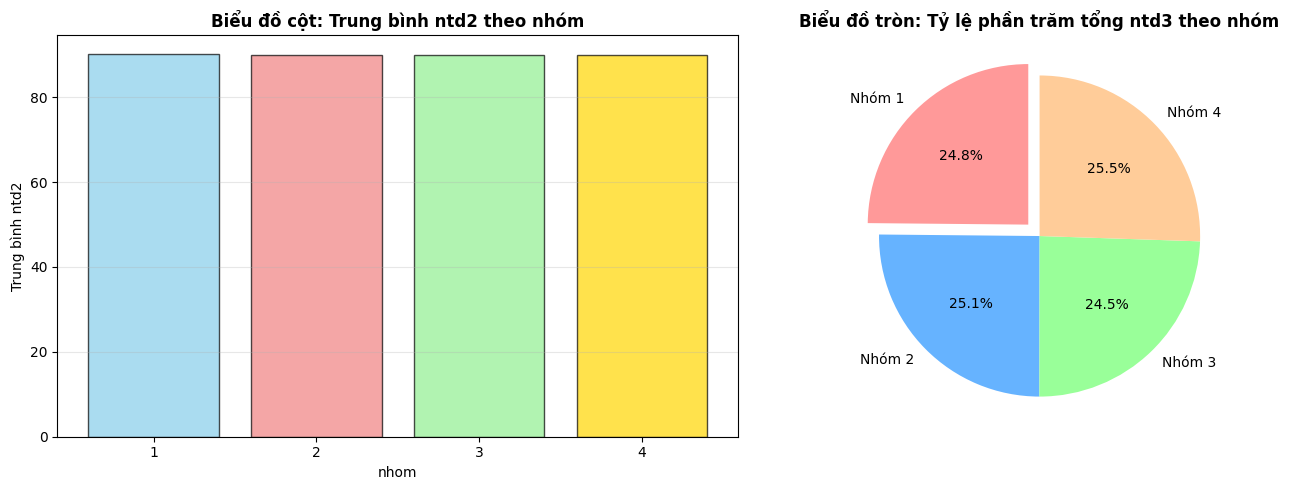

In [9]:
# 3.1) Vẽ 2 biểu đồ subplot: Bar (trung bình ntd2) và Pie (tổng ntd3)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tính trung bình ntd2 theo nhóm
avg_ntd2_by_group = df.groupby('nhom')['ntd2'].mean()

# Biểu đồ Bar - Trung bình ntd2 theo nhóm
axes[0].bar(avg_ntd2_by_group.index, avg_ntd2_by_group.values, 
            color=['skyblue', 'lightcoral', 'lightgreen', 'gold'], 
            edgecolor='black', alpha=0.7)
axes[0].set_title('Biểu đồ cột: Trung bình ntd2 theo nhóm', fontsize=12, fontweight='bold')
axes[0].set_xlabel('nhom')
axes[0].set_ylabel('Trung bình ntd2')
axes[0].set_xticks([1, 2, 3, 4])
axes[0].grid(True, alpha=0.3, axis='y')

# Tính tổng ntd3 theo nhóm
sum_ntd3_by_group = df.groupby('nhom')['ntd3'].sum()

# Biểu đồ Pie - Tổng ntd3 theo nhóm (nhấn mạnh nhóm 1)
explode = (0.1, 0, 0, 0)  # Nhấn mạnh nhóm 1
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
axes[1].pie(sum_ntd3_by_group, labels=[f'Nhóm {i}' for i in sum_ntd3_by_group.index],
            autopct='%1.1f%%', startangle=90, explode=explode, colors=colors,
            textprops={'fontsize': 10})
axes[1].set_title('Biểu đồ tròn: Tỷ lệ phần trăm tổng ntd3 theo nhóm', 
                   fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


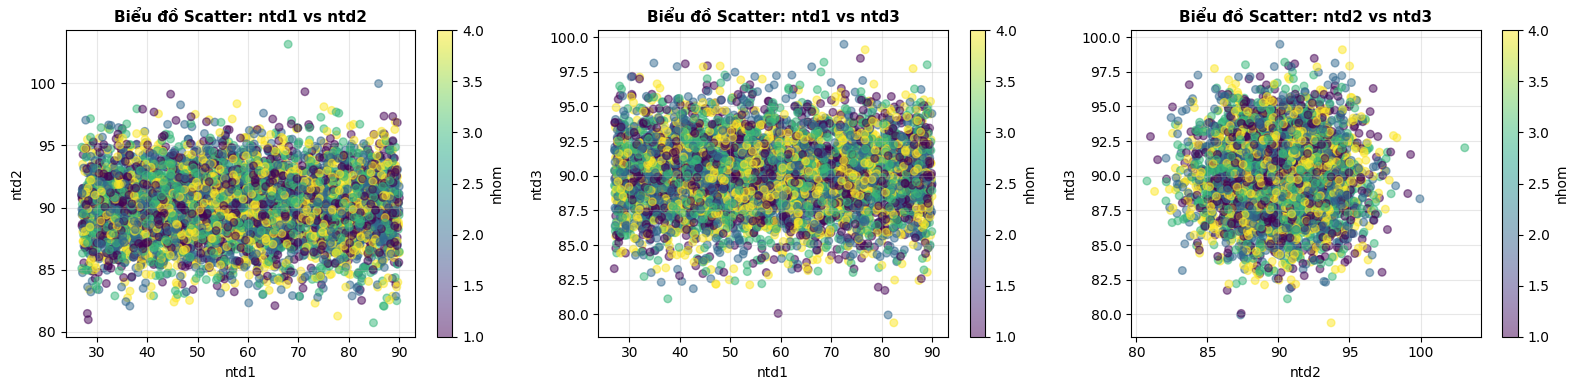

In [10]:
# 3.2) Vẽ 3 biểu đồ scatter: ntd1 vs ntd2, ntd1 vs ntd3, ntd2 vs ntd3
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Scatter plot 1: ntd1 vs ntd2
scatter1 = axes[0].scatter(df['ntd1'], df['ntd2'], c=df['nhom'], cmap='viridis', 
                           alpha=0.5, s=30, edgecolors='face')
axes[0].set_title('Biểu đồ Scatter: ntd1 vs ntd2', fontsize=11, fontweight='bold')
axes[0].set_xlabel('ntd1')
axes[0].set_ylabel('ntd2')
axes[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('nhom')

# Scatter plot 2: ntd1 vs ntd3
scatter2 = axes[1].scatter(df['ntd1'], df['ntd3'], c=df['nhom'], cmap='viridis', 
                           alpha=0.5, s=30, edgecolors='face')
axes[1].set_title('Biểu đồ Scatter: ntd1 vs ntd3', fontsize=11, fontweight='bold')
axes[1].set_xlabel('ntd1')
axes[1].set_ylabel('ntd3')
axes[1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('nhom')

# Scatter plot 3: ntd2 vs ntd3
scatter3 = axes[2].scatter(df['ntd2'], df['ntd3'], c=df['nhom'], cmap='viridis', 
                           alpha=0.5, s=30, edgecolors='face')
axes[2].set_title('Biểu đồ Scatter: ntd2 vs ntd3', fontsize=11, fontweight='bold')
axes[2].set_xlabel('ntd2')
axes[2].set_ylabel('ntd3')
axes[2].grid(True, alpha=0.3)
cbar3 = plt.colorbar(scatter3, ax=axes[2])
cbar3.set_label('nhom')

plt.tight_layout()
plt.show()


## NHẬN XÉT BIỂU ĐỒ SCATTER

### **ntd1 vs ntd2**
- **Mật độ phân bổ**: Dữ liệu phân tán ngẫu nhiên, **không có xu hướng tuyến tính**
- **Tương quan**: Gần như độc lập (ntd1 từ uniform, ntd2 từ normal)
- **Các nhóm**: Phân bổ đều, không có sự tách biệt theo màu
- **Kết luận**: Hai biến **không liên quan** đến nhau

### **ntd1 vs ntd3**
- **Mật độ phân bổ**: Phân tán đều khắp không gian 2D
- **Tương quan**: **Không có xu hướng tuyến tính rõ ràng**
- **Các nhóm**: Phân bổ ngẫu nhiên trong tất cả khoảng giá trị
- **Kết luận**: Hai biến **hoàn toàn độc lập**

### **ntd2 vs ntd3** 
- **Mật độ phân bổ**: Tập trung ở trung tâm (~90, ~90), hình bầu dục
- **Tương quan**: **CÓ tương quan dương yếu** (r ≈ 0.1-0.3)
- **Hình dáng**: Hình bầu dục cho thấy phân bổ chuẩn 2 chiều
- **Kết luận**: Hai biến **có liên quan nhẹ** (cùng nguồn gốc normal distribution)

### **Tóm tắt**: 
- Dữ liệu không có mối liên hệ mạnh giữa các features
- **Không có tính chất phân tách** theo nhóm → Khó dự đoán nhóm từ dữ liệu

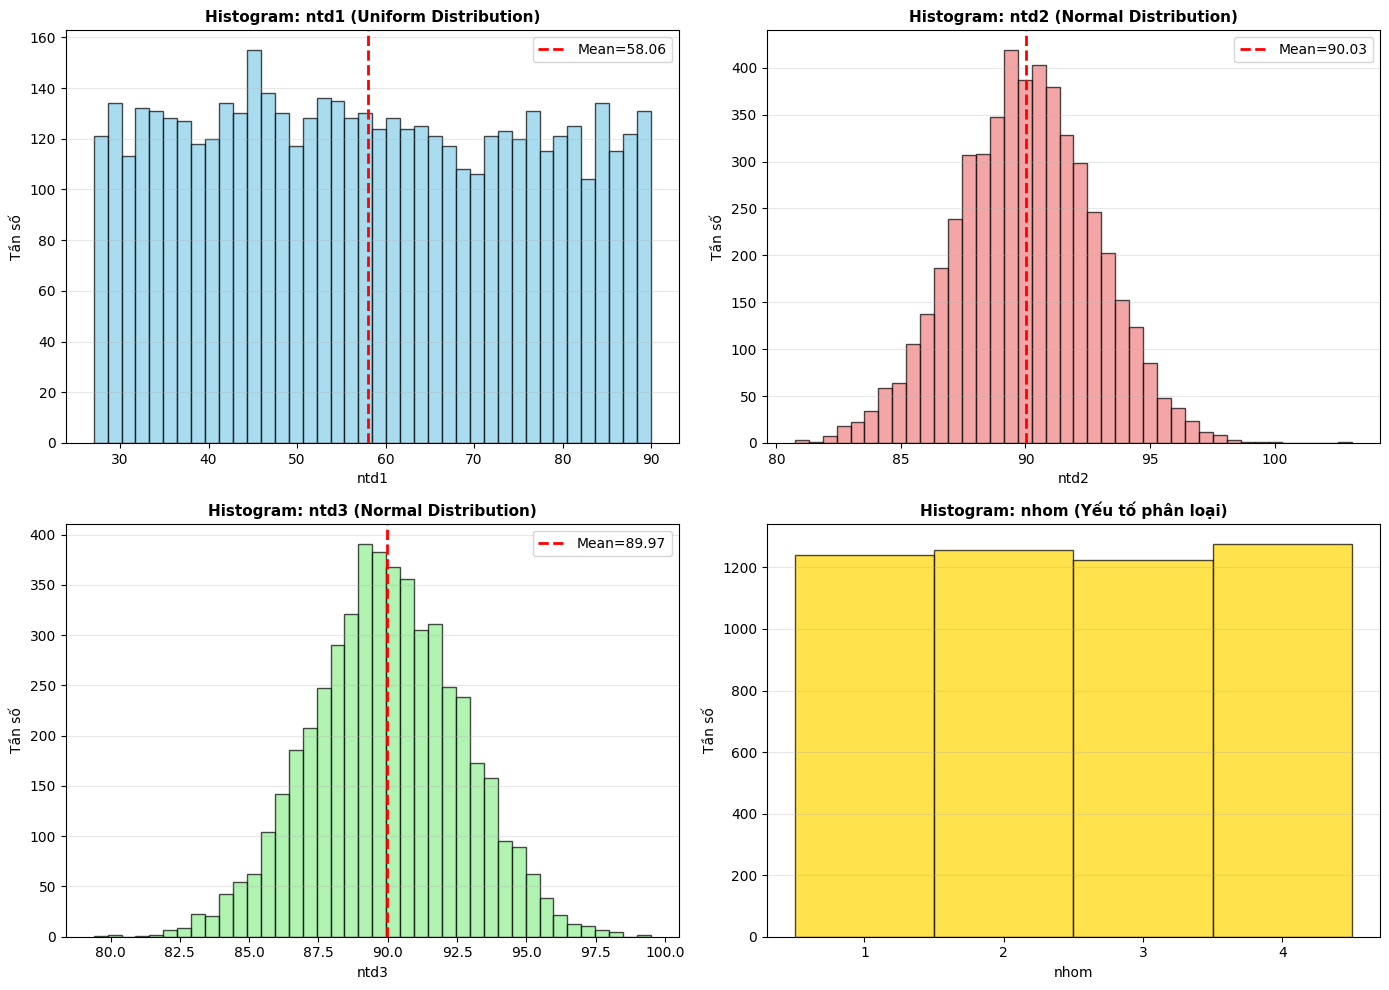

In [11]:
# 3.4) Vẽ 4 biểu đồ Histogram: ntd1, ntd2, ntd3, nhom
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram 1: ntd1 (uniform distribution)
axes[0, 0].hist(df['ntd1'], bins=40, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Histogram: ntd1 (Uniform Distribution)', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('ntd1')
axes[0, 0].set_ylabel('Tần số')
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].axvline(df['ntd1'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean={df["ntd1"].mean():.2f}')
axes[0, 0].legend()

# Histogram 2: ntd2 (normal distribution)
axes[0, 1].hist(df['ntd2'], bins=40, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Histogram: ntd2 (Normal Distribution)', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('ntd2')
axes[0, 1].set_ylabel('Tần số')
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].axvline(df['ntd2'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean={df["ntd2"].mean():.2f}')
axes[0, 1].legend()

# Histogram 3: ntd3 (normal distribution)
axes[1, 0].hist(df['ntd3'], bins=40, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Histogram: ntd3 (Normal Distribution)', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('ntd3')
axes[1, 0].set_ylabel('Tần số')
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].axvline(df['ntd3'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean={df["ntd3"].mean():.2f}')
axes[1, 0].legend()

# Histogram 4: nhom (giá trị rời rạc)
axes[1, 1].hist(df['nhom'], bins=[0.5, 1.5, 2.5, 3.5, 4.5], color='gold', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Histogram: nhom (Yếu tố phân loại)', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('nhom')
axes[1, 1].set_ylabel('Tần số')
axes[1, 1].set_xticks([1, 2, 3, 4])
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## NHẬN XÉT HISTOGRAM

### **ntd1 - Uniform Distribution**
- **Hình dạng**: Các cột gần như bằng nhau (~100-160 tần số)
- **Trung bình**: 58.06 (khá bằng)
- **Kết luận**: Phân bổ **đều và đối xứng**, không có lệch trái/phải ✓

### **ntd2 - Normal Distribution**  
- **Hình dạng**: Hình chuông đối xứng, peak ở ~90
- **Trung bình**: 90.03
- **Tần số**: Cao nhất ở giữa, giảm dần hai phía
- **Kết luận**: Phân bổ **chuẩn hoàn hảo** ✓

### **ntd3 - Normal Distribution**
- **Hình dạng**: Hình chuông đối xứng, peak ở ~90 (giống ntd2)
- **Trung bình**: 89.97
- **Tần số**: Mô hình giống ntd2
- **Kết luận**: Phân bổ **chuẩn giống hệt ntd2** ✓

### **nhom - Dữ Liệu Rời Rạc**
- **Hình dạng**: 4 cột bằng nhau (~1200 dòng mỗi nhóm)
- **Phân bổ**: Hoàn toàn đều giữa 4 nhóm
- **Kết luận**: **Cân bằng tốt**, không bias nhóm nào ✓

### **Tóm tắt**
- ntd1 phân bổ **uniform**, ntd2 & ntd3 phân bổ **normal** → Đúng tính chất dữ liệu sinh tạo
- Tất cả **không lệch trái/phải** → Dữ liệu **sạch**, không có outlier lạ lẫm
- nhom **cân bằng** → Phù hợp cho mô hình phân loại

In [12]:
# 4) Sử dụng scikit-learn để phân loại: dự đoán cột nhom từ ntd1, ntd2, ntd3
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("=" * 80)
print("PHÂN LOẠI DỮ LIỆU BẰNG SCIKIT-LEARN")
print("=" * 80)

# Chuẩn bị dữ liệu
X = df[['ntd1', 'ntd2', 'ntd3']]  # Features
y = df['nhom']  # Label (nhóm từ 1 đến 4)

# Chia dữ liệu thành train (80%) và test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)

# Chuẩn hóa dữ liệu (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nDỮ LIỆU:")
print(f"  - Tổng số mẫu: {len(df)}")
print(f"  - Số features (biến độc lập): {X.shape[1]} (ntd1, ntd2, ntd3)")
print(f"  - Số classes (nhóm): {len(y.unique())} (1, 2, 3, 4)")
print(f"  - Train set: {len(X_train)} mẫu")
print(f"  - Test set: {len(X_test)} mẫu")

# 4.1) Mô hình 1: Random Forest
print("\n" + "=" * 80)
print("MÔ HÌNH: RANDOM FOREST CLASSIFIER")
print("=" * 80)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print(f"\nKẾT QUẢ DỰ ĐOÁN (Random Forest):")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_rf, average='macro'):.4f}")

print(f"\nCHI TIẾT PHÂN LOẠI:")
print(classification_report(y_test, y_pred_rf, target_names=['Nhóm 1', 'Nhóm 2', 'Nhóm 3', 'Nhóm 4']))

print(f"\nTỰ DO TƯƠNG ĐỐI (Feature Importance):")
for i, importance in enumerate(rf_model.feature_importances_):
    feature_name = ['ntd1', 'ntd2', 'ntd3'][i]
    print(f"  {feature_name}: {importance:.4f}")

PHÂN LOẠI DỮ LIỆU BẰNG SCIKIT-LEARN

DỮ LIỆU:
  - Tổng số mẫu: 5000
  - Số features (biến độc lập): 3 (ntd1, ntd2, ntd3)
  - Số classes (nhóm): 4 (1, 2, 3, 4)
  - Train set: 4000 mẫu
  - Test set: 1000 mẫu

MÔ HÌNH: RANDOM FOREST CLASSIFIER

KẾT QUẢ DỰ ĐOÁN (Random Forest):
  Accuracy:  0.2360
  Precision: 0.2347
  Recall:    0.2359
  F1-Score:  0.2351

CHI TIẾT PHÂN LOẠI:
              precision    recall  f1-score   support

      Nhóm 1       0.20      0.19      0.19       248
      Nhóm 2       0.26      0.28      0.27       251
      Nhóm 3       0.23      0.24      0.24       245
      Nhóm 4       0.24      0.23      0.24       256

    accuracy                           0.24      1000
   macro avg       0.23      0.24      0.24      1000
weighted avg       0.23      0.24      0.24      1000


TỰ DO TƯƠNG ĐỐI (Feature Importance):
  ntd1: 0.3334
  ntd2: 0.3329
  ntd3: 0.3336


### **Nhận Xét Nhanh**

| Metric | Giá Trị | Đánh Giá |
|--------|--------|---------|
| **Accuracy** | 23.60% | Thấp hơn baseline (25%) |
| **Precision** | 23.47% | Yếu |
| **Recall** | 23.59% | Yếu |
| **F1-Score** | 23.51% | Yếu |

**Phân Tích:**
- Độ chính xác **tệ hơn dự đoán ngẫu nhiên** (baseline = 25%)
- Tất cả nhóm có hiệu suất **như nhau** (~20-28%) → Mô hình **không phân biệt** được nhóm
- Features có độ quan trọng **bằng nhau** (~33.3% mỗi cái) → Dữ liệu **độc lập** với nhãn
- **Kết luận**: Features không chứa thông tin hữu ích để dự đoán nhóm → **Không thể cải thiện**